In [2]:
!pip install opencv-python matplotlib numpy torch torchvision
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-8gqq02cx
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-8gqq02cx
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [4]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-04-07 07:15:28--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.239.50.120, 18.239.50.9, 18.239.50.18, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.239.50.120|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   305MB/s    in 1.2s    

2026-04-07 07:15:30 (305 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [5]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

In [6]:


# ================================
# 1. Load SAM model
# ================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sam_checkpoint = "sam_vit_b_01ec64.pth"
model_type = "vit_b"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=DEVICE)

mask_generator = SamAutomaticMaskGenerator(
    sam,
    points_per_side=32,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.92,
    crop_n_layers=1,
)

# ================================
# 2. Folder with Homework 2 images
# ================================
IMAGE_FOLDER = "/kaggle/input/datasets/martinkoome/segment"   # <- change to your folder
OUTPUT_FOLDER = "segmented_results"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)




Processing experiment.png...
Masks detected: 61


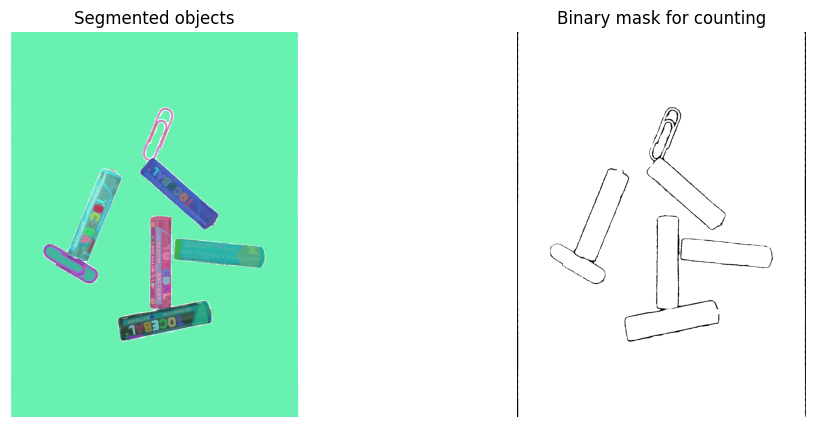


====== FINAL OBJECT COUNTS ======
experiment.png: 3 objects detected


In [7]:
# ================================
# 3. Helper: colorize masks
# ================================
def show_anns(image, anns):
    if len(anns) == 0:
        return image

    overlay = image.copy()

    for ann in anns:
        mask = ann['segmentation']
        color = np.random.randint(0,255,3)

        overlay[mask] = overlay[mask] * 0.4 + color * 0.6

    return overlay.astype(np.uint8)

# ================================
# 4. Count objects using connected components
# ================================
def count_objects_from_masks(masks):
    combined = np.zeros_like(masks[0]['segmentation'], dtype=np.uint8)

    for m in masks:
        combined = np.logical_or(combined, m['segmentation'])

    combined = combined.astype(np.uint8) * 255

    num_labels, labels_im = cv2.connectedComponents(combined)

    # subtract background
    return num_labels - 1, combined

# ================================
# 5. Process ALL images
# ================================
results = {}

for img_name in os.listdir(IMAGE_FOLDER):

    if not img_name.lower().endswith((".png",".jpg",".jpeg")):
        continue

    print(f"\nProcessing {img_name}...")

    path = os.path.join(IMAGE_FOLDER, img_name)
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # ---- SEGMENT ----
    masks = mask_generator.generate(image)

    print("Masks detected:", len(masks))

    # ---- COUNT ----
    object_count, binary_mask = count_objects_from_masks(masks)
    results[img_name] = object_count

    # ---- VISUALIZE ----
    colored = show_anns(image, masks)

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.title("Segmented objects")
    plt.imshow(colored)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Binary mask for counting")
    plt.imshow(binary_mask, cmap="gray")
    plt.axis("off")

    plt.savefig(os.path.join(OUTPUT_FOLDER, img_name))
    plt.show()

# ================================
# 6. Final report
# ================================
print("\n====== FINAL OBJECT COUNTS ======")
for k,v in results.items():
    print(f"{k}: {v} objects detected")